In [10]:
# Cell 1 — Load Data

import pandas as pd
import numpy as np
from pathlib import Path

# Load clean monthly panel
data_path = Path('data')
df = pd.read_csv(data_path / 'clean_monthly_panel.csv', parse_dates=['date'])

# Sort by date and stock
df = df.sort_values(['date', 'permno']).reset_index(drop=True)

# Check
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique stocks: {df['permno'].nunique()}")
print(f"Unique months: {df['date'].nunique()}")
print(f"\nCrisis months (market vol > 30%): {df.groupby('date')['high_vol_regime'].first().sum()}")

Shape: (1912727, 20)
Date range: 1990-01-31 00:00:00 to 2023-12-31 00:00:00
Unique stocks: 18074
Unique months: 408

Crisis months (market vol > 30%): 24


In [11]:
# Cell 2 — Monthly Stock Selection (Benchmark)

# For each month, select the 500 stocks with the lowest realized vol
# Uses real_vol_ann_lag1 (last month's vol) to avoid lookahead bias

def select_benchmark_portfolio(df, n_stocks=500):
    portfolios = []
    
    for date, month_df in df.groupby('date'):
        # Drop stocks with missing lagged vol (e.g. first month)
        available = month_df.dropna(subset=['real_vol_ann_lag1'])
        
        # Need at least 500 stocks available
        if len(available) < n_stocks:
            continue
        
        # Select 500 lowest vol stocks
        selected = available.nsmallest(n_stocks, 'real_vol_ann_lag1').copy()
        selected['date'] = date
        selected['weight'] = 1 / n_stocks  # equal weight
        portfolios.append(selected)
    
    return pd.concat(portfolios, ignore_index=True)

benchmark = select_benchmark_portfolio(df)

print(f"Benchmark shape: {benchmark.shape}")
print(f"Months covered: {benchmark['date'].nunique()}")
print(f"Stocks per month: {benchmark.groupby('date')['permno'].count().mean():.0f}")
print(f"\nAverage selected vol: {benchmark['real_vol_ann_lag1'].mean():.4f}")
print(f"Average market vol: {df.groupby('date')['mkt_vol_ann'].first().mean():.4f}")

Benchmark shape: (203500, 21)
Months covered: 407
Stocks per month: 500

Average selected vol: 0.0344
Average market vol: 0.1464


In [22]:
# Cell 3 — Calculate Net Revenue (both versions)

# Capital cost rate depends on regime
benchmark['capital_cost_rate'] = np.where(
    benchmark['high_vol_regime'] == True, 0.30, 0.15
)

# Capital cost (same for both versions)
benchmark['capital_cost'] = (
    benchmark['capital_cost_rate'] * benchmark['real_vol_ann_lag1'] / 12
)

# --- Version 1: Fixed 5% return (assignment assumption) ---
benchmark['gross_return_fixed'] = 0.05 / 12
benchmark['net_revenue_fixed']  = (
    benchmark['gross_return_fixed'] - benchmark['capital_cost']
)

# --- Version 2: Actual CRSP returns ---
benchmark['gross_return_actual'] = benchmark['ret']
benchmark['net_revenue_actual']  = (
    benchmark['gross_return_actual'] - benchmark['capital_cost']
)

# Aggregate to portfolio level
monthly_results = benchmark.groupby('date').agg(
    # Fixed version
    avg_net_revenue_fixed   = ('net_revenue_fixed', 'mean'),
    # Actual version
    avg_net_revenue_actual  = ('net_revenue_actual', 'mean'),
    avg_gross_return_actual = ('gross_return_actual', 'mean'),
    # Common
    avg_vol          = ('real_vol_ann_lag1', 'mean'),
    high_vol_regime  = ('high_vol_regime', 'first'),
    market_vol       = ('mkt_vol_ann', 'first'),
).reset_index()

# Cumulative net revenue (compound)
monthly_results['cumulative_fixed']  = (
    (1 + monthly_results['avg_net_revenue_fixed']).cumprod()
)
monthly_results['cumulative_actual'] = (
    (1 + monthly_results['avg_net_revenue_actual']).cumprod()
)

print("Version 1 (fixed 5%) avg monthly net revenue:  "
      f"{monthly_results['avg_net_revenue_fixed'].mean():.4%}")
print("Version 2 (actual returns) avg monthly net revenue: "
      f"{monthly_results['avg_net_revenue_actual'].mean():.4%}")

Version 1 (fixed 5%) avg monthly net revenue:  0.3689%
Version 2 (actual returns) avg monthly net revenue: 1.0321%


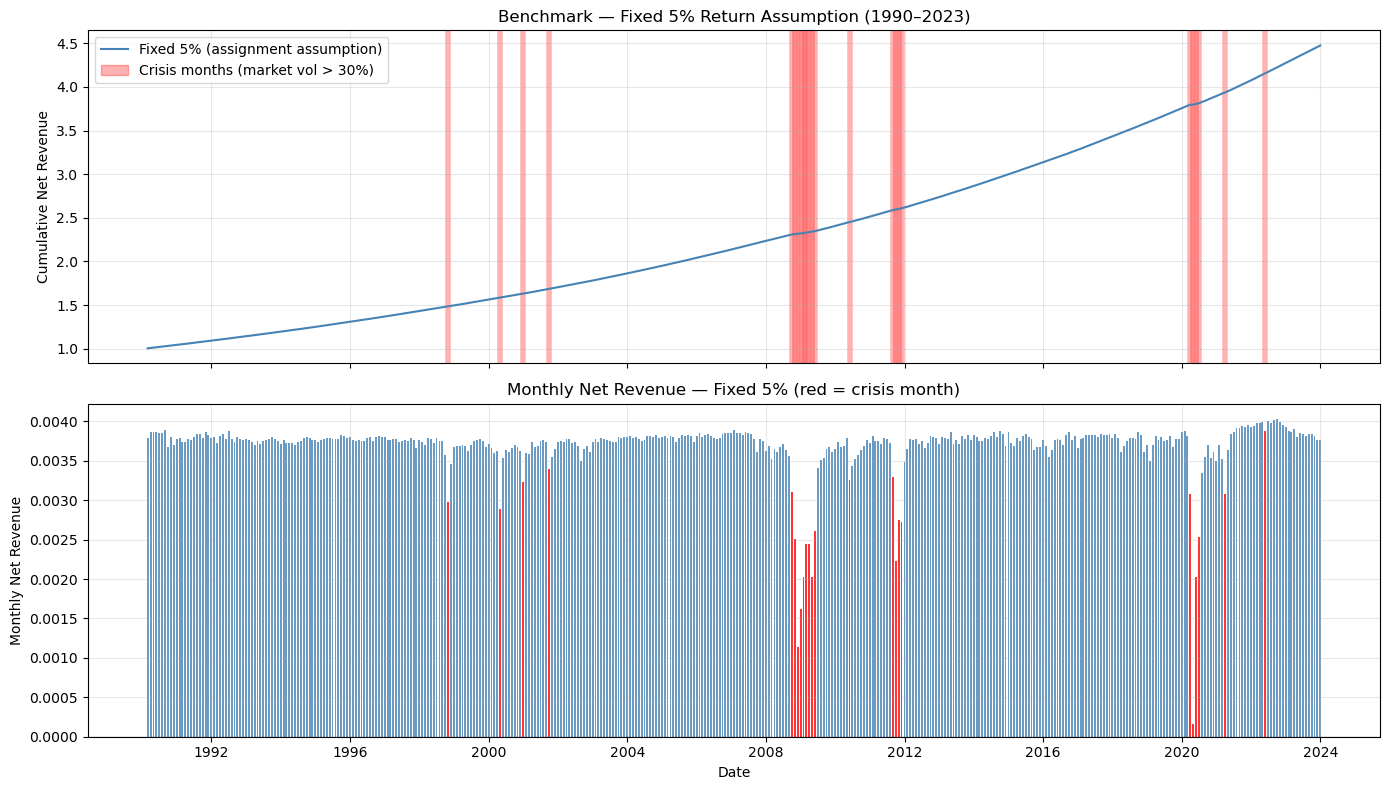

Chart 1 saved ✅


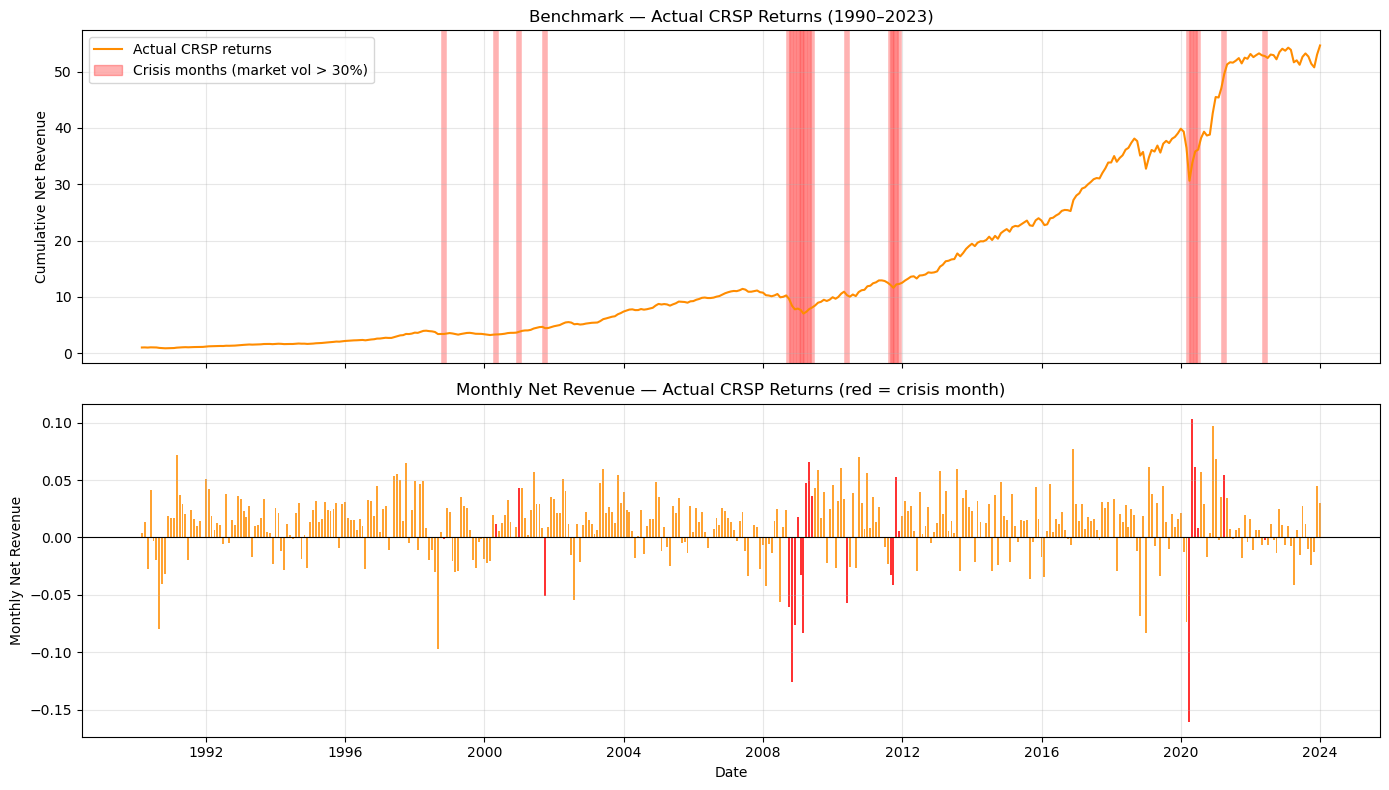

Chart 2 saved ✅


In [27]:
# Cell 4 — Plot Benchmark Performance (two separate charts)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def shade_crisis(ax, monthly_results):
    for _, row in monthly_results[monthly_results['high_vol_regime']].iterrows():
        ax.axvspan(row['date'], row['date'], alpha=0.3, color='red', linewidth=4)

crisis_patch = mpatches.Patch(color='red', alpha=0.3,
                               label='Crisis months (market vol > 30%)')

# ── Chart 1: Fixed 5% assumption ──────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(monthly_results['date'],
         monthly_results['cumulative_fixed'],
         color='steelblue', linewidth=1.5)
shade_crisis(ax1, monthly_results)
ax1.set_ylabel('Cumulative Net Revenue')
ax1.set_title('Benchmark — Fixed 5% Return Assumption (1990–2023)')
ax1.legend(handles=[
    plt.Line2D([0], [0], color='steelblue', linewidth=1.5,
               label='Fixed 5% (assignment assumption)'),
    crisis_patch
])
ax1.grid(True, alpha=0.3)

colors_fixed = ['red' if x else 'steelblue'
                for x in monthly_results['high_vol_regime']]
ax2.bar(monthly_results['date'],
        monthly_results['avg_net_revenue_fixed'],
        width=20, color=colors_fixed, alpha=0.8)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylabel('Monthly Net Revenue')
ax2.set_xlabel('Date')
ax2.set_title('Monthly Net Revenue — Fixed 5% (red = crisis month)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_path / 'benchmark_fixed_5pct.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✅")

# ── Chart 2: Actual CRSP returns ──────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(monthly_results['date'],
         monthly_results['cumulative_actual'],
         color='darkorange', linewidth=1.5)
shade_crisis(ax1, monthly_results)
ax1.set_ylabel('Cumulative Net Revenue')
ax1.set_title('Benchmark — Actual CRSP Returns (1990–2023)')
ax1.legend(handles=[
    plt.Line2D([0], [0], color='darkorange', linewidth=1.5,
               label='Actual CRSP returns'),
    crisis_patch
])
ax1.grid(True, alpha=0.3)

colors_actual = ['red' if x else 'darkorange'
                 for x in monthly_results['high_vol_regime']]
ax2.bar(monthly_results['date'],
        monthly_results['avg_net_revenue_actual'],
        width=20, color=colors_actual, alpha=0.8)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylabel('Monthly Net Revenue')
ax2.set_xlabel('Date')
ax2.set_title('Monthly Net Revenue — Actual CRSP Returns (red = crisis month)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_path / 'benchmark_actual_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved ✅")

In [28]:
# Cell 5 — Summary Statistics (both versions)

def summarise(col, label):
    mean   = monthly_results[col].mean()
    std    = monthly_results[col].std()
    sharpe = (mean / std) * np.sqrt(12)
    best   = monthly_results.loc[monthly_results[col].idxmax()]
    worst  = monthly_results.loc[monthly_results[col].idxmin()]
    normal = monthly_results[~monthly_results['high_vol_regime']]
    crisis = monthly_results[monthly_results['high_vol_regime']]

    print(f"\n{'='*55}")
    print(f"BENCHMARK — {label}")
    print(f"{'='*55}")
    print(f"\n--- FULL PERIOD (1990–2023) ---")
    print(f"Months:                    {len(monthly_results)}")
    print(f"Avg monthly net revenue:   {mean:.4%}")
    print(f"Avg annual net revenue:    {mean*12:.4%}")
    print(f"Std monthly net revenue:   {std:.4%}")
    print(f"Sharpe ratio (annualized): {sharpe:.4f}")
    print(f"Best month:  "
          f"{best['date'].strftime('%Y-%m')} ({best[col]:.4%})")
    print(f"Worst month: "
          f"{worst['date'].strftime('%Y-%m')} ({worst[col]:.4%})")
    print(f"\n--- CRISIS VS NORMAL ---")
    print(f"Normal months ({len(normal):>3}):  "
          f"avg {normal[col].mean():.4%}/month")
    print(f"Crisis months ({len(crisis):>3}):   "
          f"avg {crisis[col].mean():.4%}/month")
    print(f"Crisis performance drop:   "
          f"{(1 - crisis[col].mean()/normal[col].mean()):.1%}")
    print(f"\n--- NOTE ON STATISTICAL VALIDATION ---")
    print(f"Benchmark uses lagged vol (real_vol_ann_lag1) as")
    print(f"naive forecast. ML models OOS R² computed vs this")
    print(f"baseline in the model notebooks.")

    return {
        'annual_net_revenue' : mean * 12,
        'sharpe'             : sharpe,
        'worst_month'        : worst[col],
        'best_month'         : best[col],
        'crisis_avg'         : crisis[col].mean(),
        'normal_avg'         : normal[col].mean(),
    }

# Run for both versions
summary_fixed  = summarise('avg_net_revenue_fixed',
                            'Fixed 5% Return (Assignment Assumption)')
summary_actual = summarise('avg_net_revenue_actual',
                            'Actual CRSP Returns (Realistic Backtest)')

# Save for later comparison notebook
benchmark_summary = {
    'fixed'  : summary_fixed,
    'actual' : summary_actual
}
print(f"\n{'='*55}")
print("Benchmark summaries saved for model comparison ✅")
print(benchmark_summary)


BENCHMARK — Fixed 5% Return (Assignment Assumption)

--- FULL PERIOD (1990–2023) ---
Months:                    407
Avg monthly net revenue:   0.3689%
Avg annual net revenue:    4.4272%
Std monthly net revenue:   0.0354%
Sharpe ratio (annualized): 36.0803
Best month:  2022-09 (0.4025%)
Worst month: 2020-04 (0.0159%)

--- CRISIS VS NORMAL ---
Normal months (383):  avg 0.3760%/month
Crisis months ( 24):   avg 0.2559%/month
Crisis performance drop:   31.9%

--- NOTE ON STATISTICAL VALIDATION ---
Benchmark uses lagged vol (real_vol_ann_lag1) as
naive forecast. ML models OOS R² computed vs this
baseline in the model notebooks.

BENCHMARK — Actual CRSP Returns (Realistic Backtest)

--- FULL PERIOD (1990–2023) ---
Months:                    407
Avg monthly net revenue:   1.0321%
Avg annual net revenue:    12.3855%
Std monthly net revenue:   2.9585%
Sharpe ratio (annualized): 1.2085
Best month:  2020-04 (10.3355%)
Worst month: 2020-03 (-16.0244%)

--- CRISIS VS NORMAL ---
Normal months (383):

In [30]:
# Cell 6 — Save results using evaluation.py

import importlib
import evaluation
importlib.reload(evaluation)
from evaluation import summarise_portfolio

# --- Version 1: Fixed 5% (assignment assumption) ---
monthly_fixed = monthly_results[['date', 'avg_net_revenue_fixed', 
                                  'high_vol_regime', 'market_vol']].copy()
monthly_fixed = monthly_fixed.rename(
    columns={'avg_net_revenue_fixed': 'avg_net_revenue'}
)
summarise_portfolio(monthly_fixed, label='benchmark_fixed5pct')

# --- Version 2: Actual CRSP returns ---
monthly_actual = monthly_results[['date', 'avg_net_revenue_actual',
                                   'high_vol_regime', 'market_vol']].copy()
monthly_actual = monthly_actual.rename(
    columns={'avg_net_revenue_actual': 'avg_net_revenue'}
)
summarise_portfolio(monthly_actual, label='benchmark_actual')

  BENCHMARK_FIXED5PCT — SUMMARY STATISTICS
Months:                    407
Avg monthly net revenue:   0.3689%
Avg annual net revenue:    4.4272%
Std monthly net revenue:   0.0354%
Sharpe ratio (annualized): 36.0803
Best month:  2022-09 (0.4025%)
Worst month: 2020-04 (0.0159%)

--- CRISIS VS NORMAL ---
Normal months (383):  avg 0.3760%/month
Crisis months ( 24):  avg 0.2559%/month

--- OOS PERIOD (2010–2023) ---
Months:                    168
Avg annual net revenue:    4.4405%
Sharpe ratio (annualized): 33.2416

Saved to data/summary_benchmark_fixed5pct.json ✅
Saved to data/monthly_results_benchmark_fixed5pct.csv ✅
  BENCHMARK_ACTUAL — SUMMARY STATISTICS
Months:                    407
Avg monthly net revenue:   1.0321%
Avg annual net revenue:    12.3855%
Std monthly net revenue:   2.9585%
Sharpe ratio (annualized): 1.2085
Best month:  2020-04 (10.3355%)
Worst month: 2020-03 (-16.0244%)

--- CRISIS VS NORMAL ---
Normal months (383):  avg 1.1537%/month
Crisis months ( 24):  avg -0.9077%/mo

{'label': 'benchmark_actual',
 'full_period_annual_net_revenue': np.float64(0.12385466272628759),
 'full_period_sharpe': np.float64(1.2085257082394707),
 'full_period_worst_month': np.float64(-0.16024358319910198),
 'full_period_best_month': np.float64(0.10335459413716486),
 'crisis_avg_monthly': np.float64(-0.009077388124777428),
 'normal_avg_monthly': np.float64(0.011536800589541981),
 'oos_annual_net_revenue': np.float64(0.12850477171334693),
 'oos_sharpe': np.float64(1.1695978475779851)}